# Airborne Laser Scanner (ALS) Mission Planning

**Purpose**: end-to-end planning for a topographic ALS survey using the RIEGL VQ-480 II reference instance.  ALS sensors sweep a linear scan line perpendicular to the flight direction with a rotating mirror at high PRF (typically 150 kHz - 2 MHz), record multiple discrete echoes per pulse, and produce dense (10-100 pts/m²) point clouds for topographic, hydrologic, vegetation, or infrastructure mapping.

HyPlan exposes a generic `ALSLidar` class.  The pre-configured `RIEGL_VQ_480II` instance is built from RIEGL's publicly published datasheet (2024-08-23) and represents the 1200 kHz operating point.  Other operating points (150 / 300 / 600 / 2000 kHz) — and other vendors (Leica TerrainMapper, Optech Galaxy) — are a small datasheet-transcription task away.

**What this notebook covers**:

1. Survey parameters: swath, footprint, scan-line spacing.
2. Point-density forward calculation and inverse solvers.
3. Along-track contiguity regime map — the dominant planning constraint.
4. MTA timing envelope vs radiometric range.
5. Required line overlap.
6. End-to-end swath polygon generation for a worked survey block.
7. Terrain-aware footprint and contiguity over a sloped DEM.
8. Crab-aware swath polygon for a flight line with crosswind.

**Out of scope**: full-waveform lidars (see `LVIS`), photon-counting (NASA ATM/ATLAS), bathymetric (RIEGL VQ-880-G), multispectral (Optech Titan), and oscillating-mirror scanners — these need different abstractions, not yet in HyPlan.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from IPython.display import display


def _show_plot():
    """Display matplotlib figures without Agg-backend warnings."""
    if matplotlib.get_backend().lower() == "agg":
        for num in plt.get_fignums():
            display(plt.figure(num))
    else:
        plt.show()


from hyplan import ureg
from hyplan.instruments import ALSLidar, ContiguityError, RIEGL_VQ_480II

## 1. Instrument summary

The pre-configured `RIEGL_VQ_480II` instance.  Every value traces back to the RIEGL datasheet (see `RIEGL_VQ_480II.source` for URL + retrieval date).

In [2]:
sensor = RIEGL_VQ_480II

print(f"Name:           {sensor.name}")
print(f"PRF:            {sensor.prf.to('kilohertz'):~.0f}")
print(f"Scan rate:      {sensor.scan_rate:~.0f}")
print(f"Scan half-angle: ±{sensor.scan_half_angle:~.1f} (FOV {2*sensor.scan_half_angle:~.0f} total)")
print(f"Beam divergence: {sensor.beam_divergence.to('milliradian'):~.2f}")
print(f"Wavelength:     {sensor.wavelength:~.0f}")
print(f"Max range:      {sensor.max_range:~.0f} (at {sensor.max_range_reflectivity:.0%} reflectivity)")
print(f"MTA zones:      {sensor.mta_zones}")
print(f"Scan geometry:  {sensor.scan_geometry}")
print()
print("Source:")
print(" ", sensor.source)

Name:           RIEGL VQ-480 II
PRF:            1200 kHz
Scan rate:      200 Hz
Scan half-angle: ±37.5 deg (FOV 75 deg total)
Beam divergence: 0.35 mrad
Wavelength:     1550 nm
Max range:      1050 m (at 60% reflectivity)
MTA zones:      9
Scan geometry:  rotating_polygon_active_arc

Source:
  RIEGL VQ-480 II Data Sheet, 2024-08-23, public datasheet PDF retrieved 2026-05-15 from https://www.riegl.com/fileadmin/media/Products/03_Airborne_Scanning/RIEGL_VQ-480_II/RIEGL_VQ-480II_Datasheet_2024-08-23.pdf (1200 kHz operating point: 1050 m max range at 60% reflectivity, 9 MTA zones; published 1700 ft AGL @ 120 kn → ~15.28 pts/m² example.  Scan rate 200 Hz chosen mid-range of published 30-300 lines/sec envelope.  ±37.5° scan = 75° total FOV.  Beam divergence ≤0.35 mrad.)


## 2. Swath geometry vs altitude

Total swath = 2 × AGL × tan(scan_half_angle).  At ±37.5° this is `~1.534 × AGL`.

Compare against the datasheet's published swath table for FOV ±37.5° (rounded to 10 m grid in the brochure).

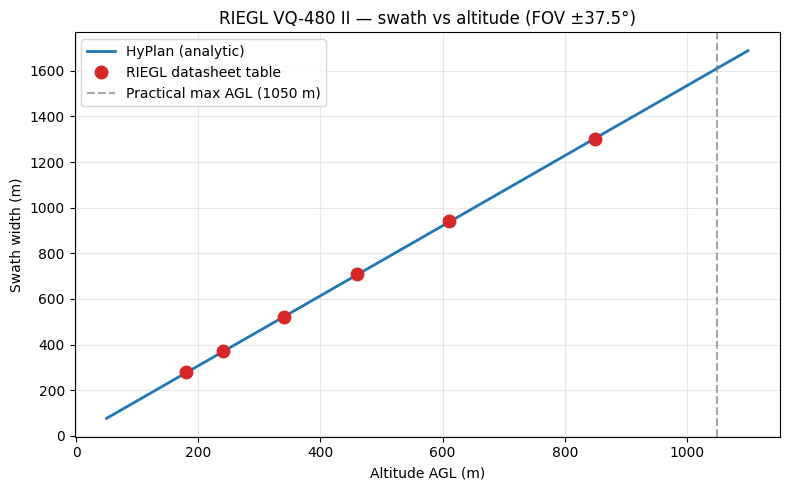

In [3]:
datasheet = pd.DataFrame({
    'agl_m': [180, 240, 340, 460, 610, 850],
    'swath_m': [280, 370, 520, 710, 940, 1300],
})

agls = np.linspace(50, 1100, 200)
swaths = [sensor.swath_width(a * ureg.meter).m_as('meter') for a in agls]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(agls, swaths, '-', lw=2, label='HyPlan (analytic)')
ax.plot(datasheet['agl_m'], datasheet['swath_m'], 'o', ms=9,
        color='C3', label='RIEGL datasheet table')
ax.axvline(sensor.mta_practical_max_altitude().m_as('meter'),
           color='gray', ls='--', alpha=0.7,
           label=f'Practical max AGL ({sensor.mta_practical_max_altitude():~.0f})')
ax.set_xlabel('Altitude AGL (m)')
ax.set_ylabel('Swath width (m)')
ax.set_title(f'{sensor.name} — swath vs altitude (FOV ±37.5°)')
ax.grid(alpha=0.3)
ax.legend(loc='upper left')
fig.tight_layout()
_show_plot()

Reproducibility within rounding precision — datasheet points lie on the analytic line.  This is the audit trail that the model is grounded in published specs, not proprietary information.

## 3. Footprint and cross-track spacing

Nadir footprint = AGL × beam_divergence (≈ 0.35 mrad for the VQ-480 II).  At the scan edge, the slant range stretches by 1/cos(θ), so the along-scan-line footprint grows by 1/cos(θ).  Cross-track pulse spacing at angle θ grows by 1/cos²(θ) for a constant-angular-velocity rotating-polygon scanner.

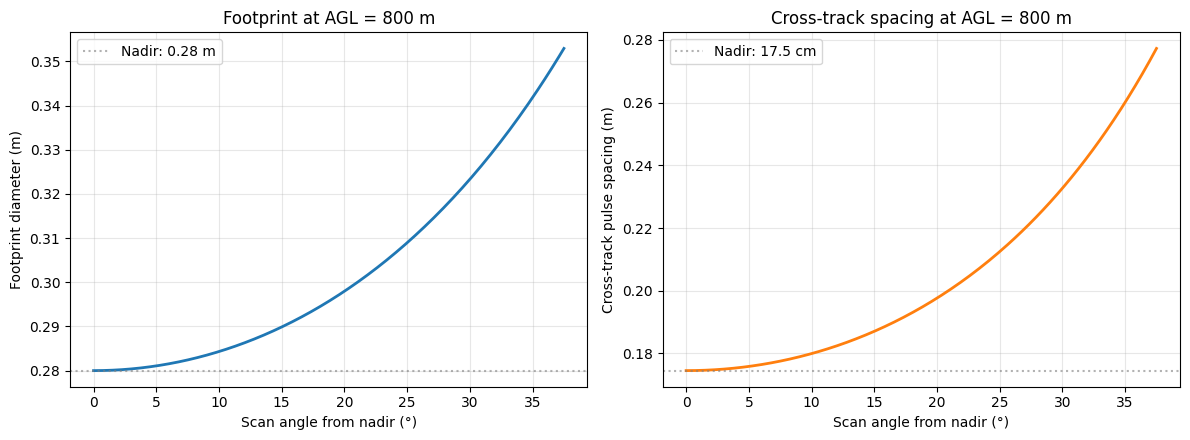

In [4]:
alt = 800 * ureg.meter
thetas_deg = np.linspace(0, 37.5, 200)
footprints = [sensor.footprint_diameter(alt, scan_angle=t*ureg.degree).m_as('meter')
              for t in thetas_deg]
spacings = [sensor.cross_track_spacing_at_angle(alt, t*ureg.degree).m_as('meter')
            for t in thetas_deg]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(thetas_deg, footprints, lw=2)
ax1.axhline(footprints[0], color='gray', ls=':', alpha=0.6,
            label=f'Nadir: {footprints[0]:.2f} m')
ax1.set_xlabel('Scan angle from nadir (°)')
ax1.set_ylabel('Footprint diameter (m)')
ax1.set_title(f'Footprint at AGL = {alt:~.0f}')
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(thetas_deg, spacings, lw=2, color='C1')
ax2.axhline(spacings[0], color='gray', ls=':', alpha=0.6,
            label=f'Nadir: {spacings[0]*100:.1f} cm')
ax2.set_xlabel('Scan angle from nadir (°)')
ax2.set_ylabel('Cross-track pulse spacing (m)')
ax2.set_title(f'Cross-track spacing at AGL = {alt:~.0f}')
ax2.grid(alpha=0.3)
ax2.legend()
fig.tight_layout()
_show_plot()

Both quantities grow toward the scan edge — point density degrades from nadir outward.

## 4. Nominal point density vs altitude and groundspeed

`point_density` returns the **nominal** density: total pulses per unit time divided by nominal swath-rectangle area per unit time.  Single closed-form expression suitable for both forward calc and inverse solving.

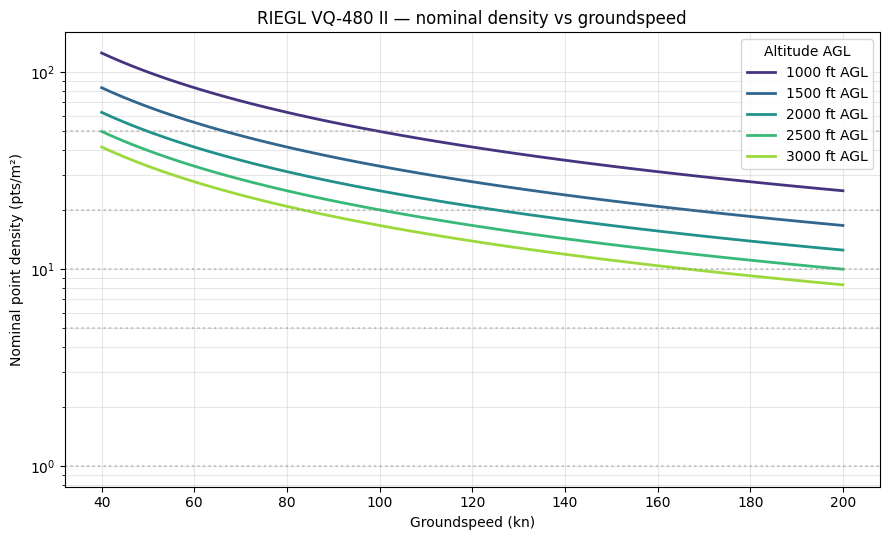

In [5]:
groundspeeds_kn = np.linspace(40, 200, 100)
altitudes_ft = [1000, 1500, 2000, 2500, 3000]

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(altitudes_ft)))
for alt_ft, color in zip(altitudes_ft, colors):
    a = alt_ft * ureg.foot
    densities = [sensor.point_density(a, gs*ureg.knot).m_as(1/ureg.meter**2)
                 for gs in groundspeeds_kn]
    ax.plot(groundspeeds_kn, densities, lw=2, color=color,
            label=f'{alt_ft} ft AGL')

ax.set_yscale('log')
ax.set_xlabel('Groundspeed (kn)')
ax.set_ylabel('Nominal point density (pts/m²)')
ax.set_title(f'{sensor.name} — nominal density vs groundspeed')
ax.grid(which='both', alpha=0.3)
ax.legend(loc='upper right', title='Altitude AGL')
for ref in [1, 5, 10, 20, 50]:
    ax.axhline(ref, color='gray', ls=':', alpha=0.4)
fig.tight_layout()
_show_plot()

## 5. Along-track contiguity regime

The dominant planning constraint for ALS: consecutive scan lines must overlap on the ground (gap ≤ nadir footprint).  Gap is purely kinematic — `groundspeed / scan_rate` — and cannot be closed by altering altitude or scan angle.  Below: which (altitude, groundspeed) combinations produce contiguous coverage?

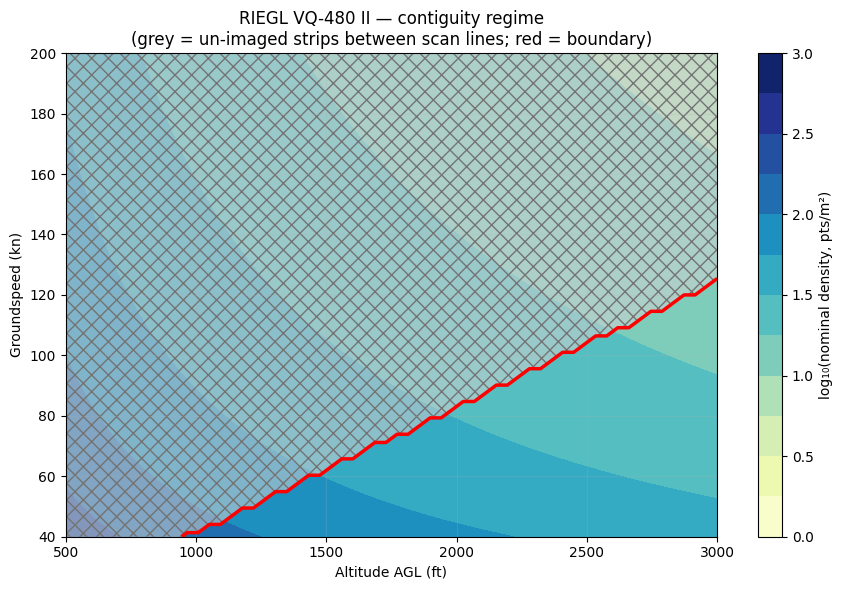

In [6]:
alt_grid_ft = np.linspace(500, 3000, 60)
gs_grid_kn = np.linspace(40, 200, 60)
A, G = np.meshgrid(alt_grid_ft, gs_grid_kn, indexing='ij')
contig = np.zeros_like(A, dtype=bool)
density = np.zeros_like(A)

for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        a = A[i, j] * ureg.foot
        g = G[i, j] * ureg.knot
        contig[i, j] = sensor.is_along_track_contiguous(a, g)
        density[i, j] = sensor.point_density(a, g).m_as(1/ureg.meter**2)

fig, ax = plt.subplots(figsize=(9, 6))
# Background: nominal density (log) as colour
im = ax.contourf(A, G, np.log10(density),
                 levels=np.linspace(0, 3, 13), cmap='YlGnBu')
cb = fig.colorbar(im, ax=ax)
cb.set_label('log₁₀(nominal density, pts/m²)')

# Overlay: contiguity boundary (white shading where non-contiguous)
ax.contour(A, G, contig.astype(int), levels=[0.5], colors='red',
           linewidths=2.5)
ax.contourf(A, G, (~contig).astype(int), levels=[0.5, 1.5],
            colors=['none'], hatches=['xx'], alpha=0)
ax.contourf(A, G, contig.astype(int), levels=[-0.5, 0.5],
            colors='lightgray', alpha=0.55)

ax.set_xlabel('Altitude AGL (ft)')
ax.set_ylabel('Groundspeed (kn)')
ax.set_title(f'{sensor.name} — contiguity regime\n'
             '(grey = un-imaged strips between scan lines; red = boundary)')
ax.grid(alpha=0.2)
fig.tight_layout()
_show_plot()

The grey region marks configurations where consecutive scan lines leave gaps — slowing down, raising the altitude (bigger footprint), or selecting a faster scan rate moves the operating point into the contiguous region.

## 6. Inverse solvers — target a specific density

Given a target density and a groundspeed, what altitude do we need?  The solvers invert the nominal-density formula and raise `ContiguityError` if the solution leaves un-imaged strips.

In [7]:
target = 20.0 / ureg.meter**2
gs = 120 * ureg.knot

try:
    alt = sensor.solve_for_altitude(target, gs)
    print(f"Altitude for {target} at {gs}: {alt.to('meter'):.0f} ({alt.to('foot'):.0f})")
except ContiguityError as e:
    print(f"ContiguityError: {e}")

# Accept the gap explicitly:
alt = sensor.solve_for_altitude(target, gs, strict_contiguity=False)
print(f"\nWith strict_contiguity=False: {alt.to('meter'):.0f}")

ContiguityError: Solved altitude 633 m at groundspeed 61.7 m/s yields the target density nominally but along-track gap 0.31 m exceeds nadir footprint 0.22 m — scan lines do not overlap.  Slow the aircraft, raise the altitude (larger footprint), or pass strict_contiguity=False to accept the gap.

With strict_contiguity=False: 633 meter


## 7. Coverage diagnostic — per-dimension breakdown

`coverage_diagnostic()` returns nadir, edge, and swath-mean density side-by-side so survey planners can see the full distribution at a glance.

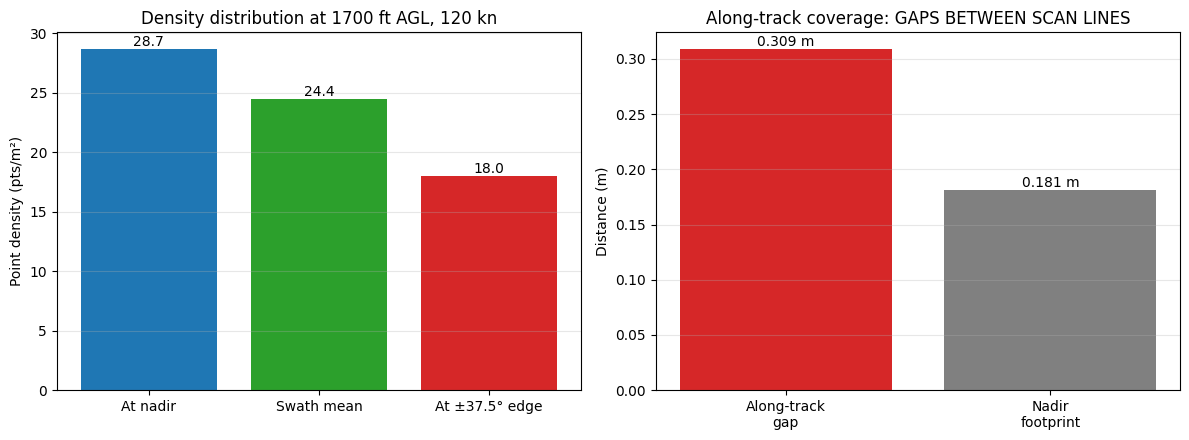

In [8]:
alt = 1700 * ureg.foot
gs = 120 * ureg.knot
diag = sensor.coverage_diagnostic(alt, gs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Density bars
bars = ['nadir_density_pts_m2', 'swath_mean_density_pts_m2', 'edge_density_pts_m2']
labels = ['At nadir', 'Swath mean', 'At ±37.5° edge']
vals = [diag[b] for b in bars]
ax1.bar(labels, vals, color=['C0', 'C2', 'C3'])
for i, v in enumerate(vals):
    ax1.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=10)
ax1.set_ylabel('Point density (pts/m²)')
ax1.set_title(f'Density distribution at {alt:~.0f} AGL, {gs:~.0f}')
ax1.grid(axis='y', alpha=0.3)

# Along-track gap vs footprint
gap_fp = ['along_track_gap_m', 'along_track_footprint_m']
gap_labels = ['Along-track\ngap', 'Nadir\nfootprint']
gap_vals = [diag[k] for k in gap_fp]
bar_colors = ['C3' if diag['along_track_gap_m'] > diag['along_track_footprint_m'] else 'C2',
              'gray']
ax2.bar(gap_labels, gap_vals, color=bar_colors)
for i, v in enumerate(gap_vals):
    ax2.text(i, v, f'{v:.3f} m', ha='center', va='bottom', fontsize=10)
ax2.set_ylabel('Distance (m)')
title_status = ("CONTIGUOUS" if diag['along_track_contiguous']
                else "GAPS BETWEEN SCAN LINES")
ax2.set_title(f'Along-track coverage: {title_status}')
ax2.grid(axis='y', alpha=0.3)
fig.tight_layout()
_show_plot()

## 8. MTA timing vs radiometric range

Multi-Time-of-Arrival processing lets the receiver disambiguate echoes from multiple in-flight pulses.  Unambiguous range per zone = `c / (2 × PRF)`.  With 9 zones at 1200 kHz, the timing envelope is ~1124 m.  The radiometric envelope (`max_range`) is 1050 m at 60% reflectivity.  The practical planning ceiling is the smaller of the two.

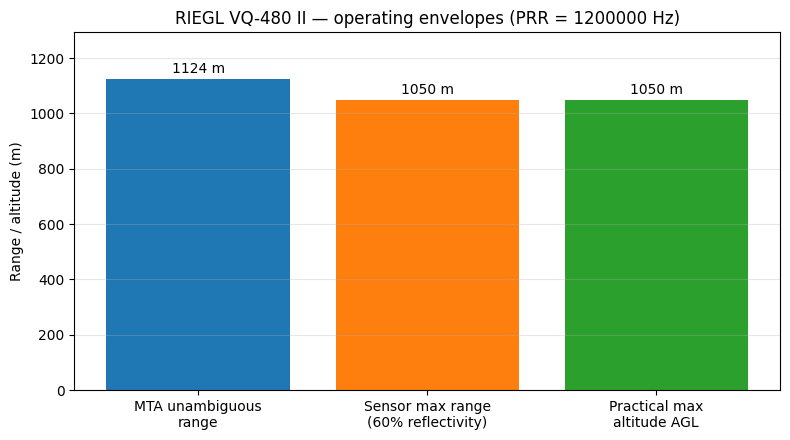

In [9]:
envelopes = {
    'MTA unambiguous\nrange': sensor.mta_max_unambiguous_range().m_as('meter'),
    'Sensor max range\n(60% reflectivity)': sensor.max_range.m_as('meter'),
    'Practical max\naltitude AGL': sensor.mta_practical_max_altitude().m_as('meter'),
}

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['C0', 'C1', 'C2']
bars = ax.bar(envelopes.keys(), envelopes.values(), color=colors)
for bar, v in zip(bars, envelopes.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 20,
            f'{v:.0f} m', ha='center', fontsize=10)
ax.set_ylabel('Range / altitude (m)')
ax.set_title(f'{sensor.name} — operating envelopes (PRR = {sensor.prf:~.0f})')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(envelopes.values()) * 1.15)
fig.tight_layout()
_show_plot()

## 9. Required adjacent-line overlap

The default 20% overlap is a small non-zero pad for crab-angle / lateral track-keeping error.  When a target density is supplied with a groundspeed, the helper instead computes the overlap that brings the *combined* density across the line boundary to target.

In [10]:
print(f"Default overlap (no target density): {sensor.required_overlap_percent(1000*ureg.meter):.1f}%")
print(f"Custom default: {sensor.required_overlap_percent(1000*ureg.meter, default_overlap_percent=15):.1f}%")

Default overlap (no target density): 20.0%
Custom default: 15.0%


## 10. End-to-end: swath polygon over a flight line

The `ALSLidar` class satisfies the `ScanningSensor` Protocol and plugs directly into `hyplan.swath.generate_swath_polygon` — no custom integration needed.  Below: generate a swath polygon for a 10 km flight line and map it.

Swath polygon: 13 vertices, valid=True
  min_width: 4253 m
  mean_width: 4282 m
  max_width: 4318 m


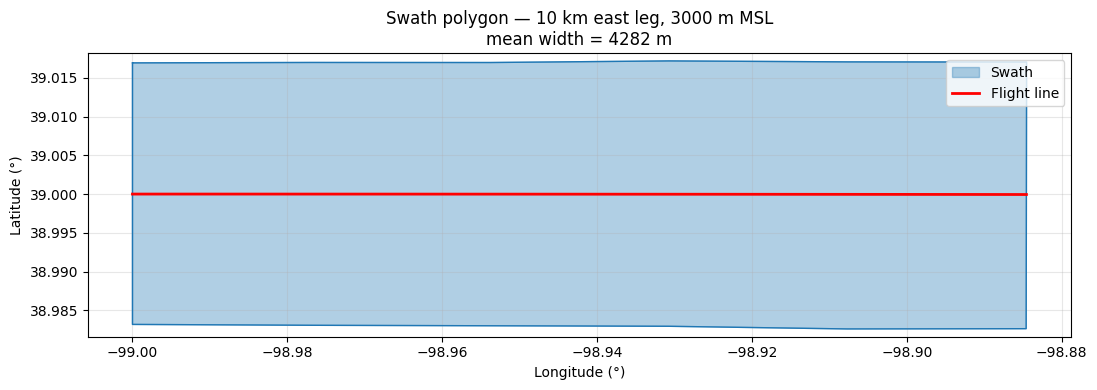

In [11]:
from hyplan import FlightLine
from hyplan.swath import calculate_swath_widths, generate_swath_polygon

line = FlightLine.start_length_azimuth(
    lat1=39.0, lon1=-99.0,
    length=10 * ureg.kilometer,
    az=90.0,
    altitude_msl=3000 * ureg.meter,
)
poly = generate_swath_polygon(line, sensor, along_precision=2000.0)
widths = calculate_swath_widths(poly)

print(f"Swath polygon: {len(poly.exterior.coords)} vertices, valid={poly.is_valid}")
for k, v in widths.items():
    print(f"  {k}: {v:.0f} m")

# Plot the swath polygon with the flight line overlaid
fig, ax = plt.subplots(figsize=(11, 4))
x, y = poly.exterior.xy
ax.fill(x, y, alpha=0.35, color='C0', label='Swath')
ax.plot(x, y, color='C0', lw=1)
track = line.track(precision=500.0)
track_lons = [pt[0] for pt in track.coords]
track_lats = [pt[1] for pt in track.coords]
ax.plot(track_lons, track_lats, 'r-', lw=2, label='Flight line')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title(
    f'Swath polygon — 10 km east leg, 3000 m MSL\n'
    f'mean width = {widths["mean_width"]:.0f} m'
)
ax.legend(loc='upper right')
ax.set_aspect('equal', adjustable='datalim')
ax.grid(alpha=0.3)
fig.tight_layout()
_show_plot()

## 11. Terrain-aware planning over a real flight line

The flat-earth methods above assume horizontal ground.  For real surveys, `ALSLidar` exposes three terrain-aware helpers that ray-trace the laser against a DEM (matching the pattern in `hyplan.instruments.LVIS`):

* `footprint_on_terrain(...)` — single-position laser footprint with surface incidence angle and elliptical footprint axes.
* `effective_swath_on_terrain(...)` — full cross-track scan with per-position metrics, two-axis contiguity (along-track + cross-track), and effective swath as the longest contiguous block.
* `terrain_summary(...)` — combined flat-earth + terrain summary at a single position.

Worked example modelled on the LVIS notebook's Denali analysis but scaled to ALS altitudes: a 6 km east-west flight line crossing **Santa Catalina Island, CA** (terrain ranges 150–475 m MSL with a central ridge), aircraft at 1000 m MSL → AGL 525–856 m everywhere, comfortably within the VQ-480 II 1050 m envelope.

**Note**: the cells below auto-download a Copernicus GLO-30 DEM tile (network access required).

In [12]:
from hyplan.terrain import generate_demfile, get_elevations
from hyplan.geometry import process_linestring
from hyplan import FlightLine

# 6 km E-W flight line over Catalina centered on Mt. Orizaba area.
fl_terrain = FlightLine.center_length_azimuth(
    lat=33.40, lon=-118.42,
    length=6 * ureg.kilometer,
    az=90.0,  # eastbound — cross-track scan goes N-S, perpendicular
    altitude_msl=1000 * ureg.meter,
    site_name='Santa Catalina Island',
)

# Auto-download a DEM tile for the area.
dem_file = generate_demfile(33.40, -118.42)

# Sample along-track positions every 300 m.
lats_track, lons_track, headings_track, *_ = process_linestring(
    fl_terrain.track(precision=300.0),
)
n_along = len(lats_track)
altitude_msl = fl_terrain.altitude_msl.m_as('meter')

terrain_elev = get_elevations(lats_track, lons_track, dem_file)
print(f'Flight line:  {fl_terrain.site_name}')
print(f'  {n_along} along-track positions, sampled every 300 m')
print(f'  Aircraft MSL: {altitude_msl:.0f} m')
print(f'  Terrain MSL:  {terrain_elev.min():.0f} – {terrain_elev.max():.0f} m')
print(f'  AGL range:    {altitude_msl - terrain_elev.max():.0f} – '
      f'{altitude_msl - terrain_elev.min():.0f} m')

Flight line:  Santa Catalina Island
  21 along-track positions, sampled every 300 m
  Aircraft MSL: 1000 m
  Terrain MSL:  144 – 475 m
  AGL range:    525 – 856 m


In [13]:
# Sweep along-track positions, collect 2D arrays:
#   (along-track position) × (scan angle).
n_scan = 31
alt_axis = ('along', 'scan')

all_inc = np.full((n_along, n_scan), np.nan)
all_fp_minor = np.full((n_along, n_scan), np.nan)
all_fp_major = np.full((n_along, n_scan), np.nan)
all_pulse_sp = np.full((n_along, n_scan), np.nan)
all_density = np.full((n_along, n_scan), np.nan)
all_cont = np.full((n_along, n_scan), False)
all_gnd_lats = np.full((n_along, n_scan), np.nan)
all_gnd_lons = np.full((n_along, n_scan), np.nan)
all_gnd_alts = np.full((n_along, n_scan), np.nan)
scan_angles = None

for i in range(n_along):
    res = sensor.effective_swath_on_terrain(
        lat=lats_track[i], lon=lons_track[i],
        altitude_msl=altitude_msl,
        heading=headings_track[i],
        groundspeed=60 * ureg.knot,
        dem_file=dem_file,
        n_scan_positions=n_scan,
    )
    if scan_angles is None:
        scan_angles = res['scan_angles_deg']
    all_inc[i, :] = res['incidence_angles_deg']
    all_fp_minor[i, :] = res['footprint_minor_m']
    all_fp_major[i, :] = res['footprint_major_m']
    all_pulse_sp[i, :] = res['pulse_spacings_m']
    all_density[i, :] = res['local_densities_pts_m2']
    all_cont[i, :] = res['contiguous_mask']
    all_gnd_lats[i, :] = res['ground_lats']
    all_gnd_lons[i, :] = res['ground_lons']
    all_gnd_alts[i, :] = res['ground_alts_m']

# Along-track distance for x-axis of pcolormesh plots.
import pymap3d.vincenty
along_dist_km = np.zeros(n_along)
for i in range(1, n_along):
    d, _ = pymap3d.vincenty.vdist(
        lats_track[0], lons_track[0],
        lats_track[i], lons_track[i],
    )
    along_dist_km[i] = float(d) / 1000.0
print(f'Built 2D arrays of shape {all_inc.shape}.  '
      f'Contiguous fraction over entire scan × track: '
      f'{all_cont.sum() / all_cont.size:.1%}')

Built 2D arrays of shape (21, 31).  Contiguous fraction over entire scan × track: 100.0%


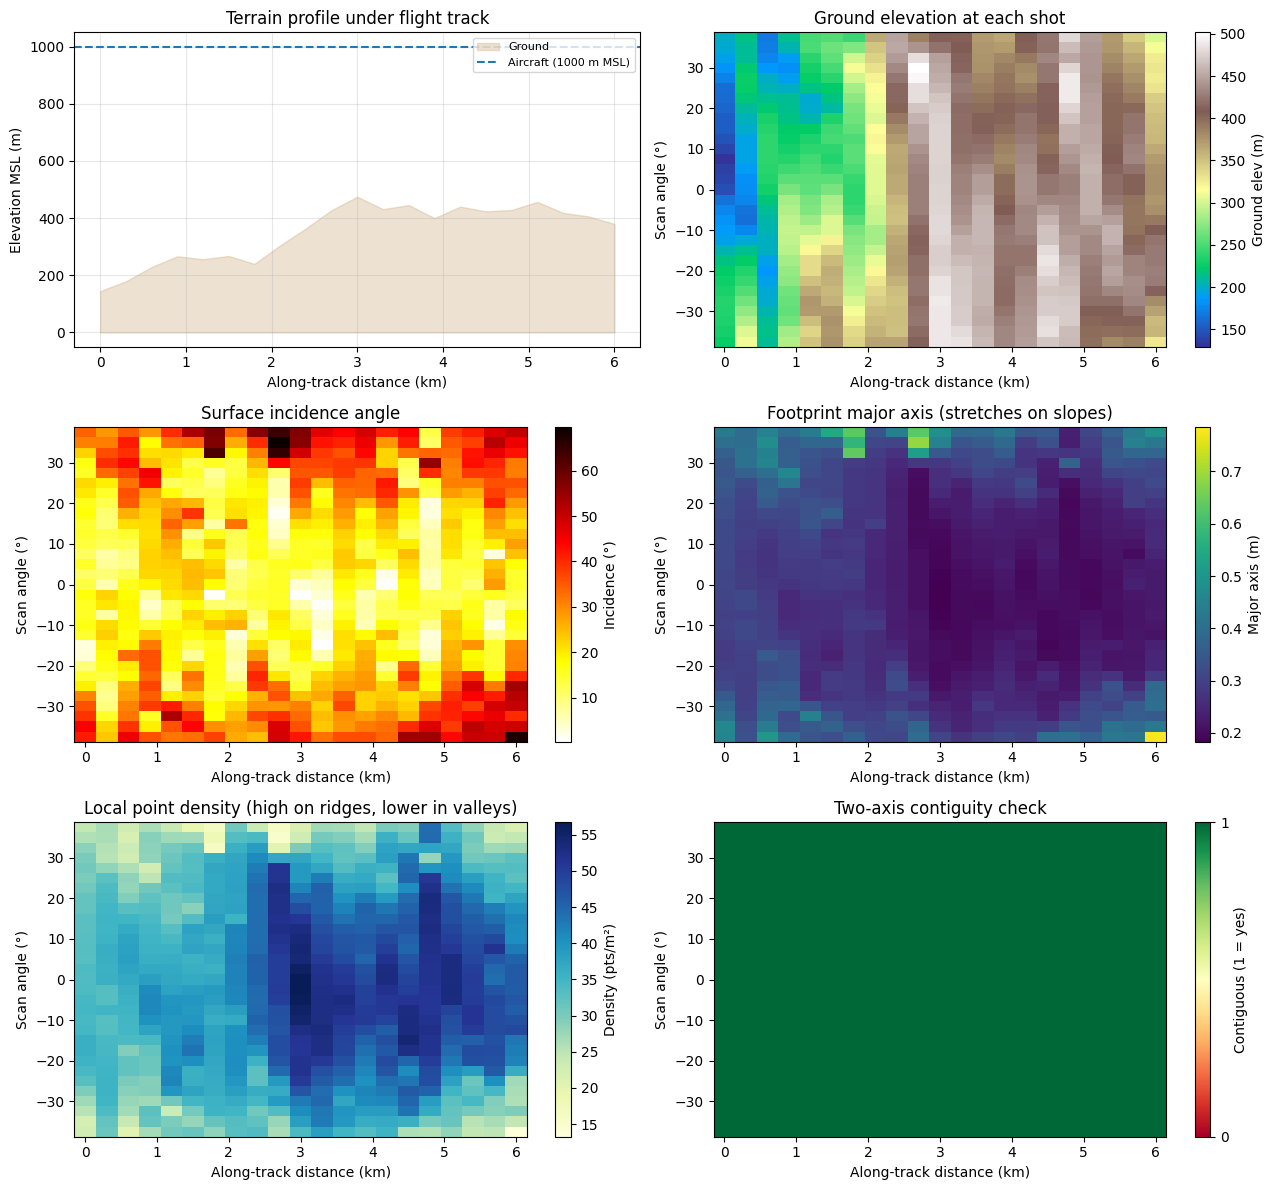

In [14]:
# 2D maps along the flight line
fig, axes = plt.subplots(3, 2, figsize=(13, 12))
ALONG, SCAN = np.meshgrid(along_dist_km, scan_angles, indexing='ij')

# (a) Terrain profile under the flight line
ax = axes[0, 0]
ax.fill_between(along_dist_km, 0, terrain_elev,
                color='tan', alpha=0.4, label='Ground')
ax.axhline(altitude_msl, color='C0', ls='--',
           label=f'Aircraft ({altitude_msl:.0f} m MSL)')
ax.set_xlabel('Along-track distance (km)')
ax.set_ylabel('Elevation MSL (m)')
ax.set_title('Terrain profile under flight track')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)

# (b) Ground elevation across (along × scan)
ax = axes[0, 1]
im = ax.pcolormesh(ALONG, SCAN, all_gnd_alts, cmap='terrain', shading='auto')
fig.colorbar(im, ax=ax, label='Ground elev (m)')
ax.set_xlabel('Along-track distance (km)')
ax.set_ylabel('Scan angle (°)')
ax.set_title('Ground elevation at each shot')

# (c) Surface incidence angle
ax = axes[1, 0]
im = ax.pcolormesh(ALONG, SCAN, all_inc, cmap='hot_r', shading='auto')
fig.colorbar(im, ax=ax, label='Incidence (°)')
ax.set_xlabel('Along-track distance (km)')
ax.set_ylabel('Scan angle (°)')
ax.set_title('Surface incidence angle')

# (d) Footprint major axis
ax = axes[1, 1]
im = ax.pcolormesh(ALONG, SCAN, all_fp_major, cmap='viridis', shading='auto')
fig.colorbar(im, ax=ax, label='Major axis (m)')
ax.set_xlabel('Along-track distance (km)')
ax.set_ylabel('Scan angle (°)')
ax.set_title('Footprint major axis (stretches on slopes)')

# (e) Local point density
ax = axes[2, 0]
im = ax.pcolormesh(ALONG, SCAN, all_density, cmap='YlGnBu', shading='auto')
fig.colorbar(im, ax=ax, label='Density (pts/m²)')
ax.set_xlabel('Along-track distance (km)')
ax.set_ylabel('Scan angle (°)')
ax.set_title('Local point density (high on ridges, lower in valleys)')

# (f) Contiguity mask
ax = axes[2, 1]
im = ax.pcolormesh(
    ALONG, SCAN, all_cont.astype(int),
    cmap='RdYlGn', shading='auto', vmin=0, vmax=1,
)
fig.colorbar(im, ax=ax, label='Contiguous (1 = yes)', ticks=[0, 1])
ax.set_xlabel('Along-track distance (km)')
ax.set_ylabel('Scan angle (°)')
ax.set_title('Two-axis contiguity check')

fig.tight_layout()
_show_plot()

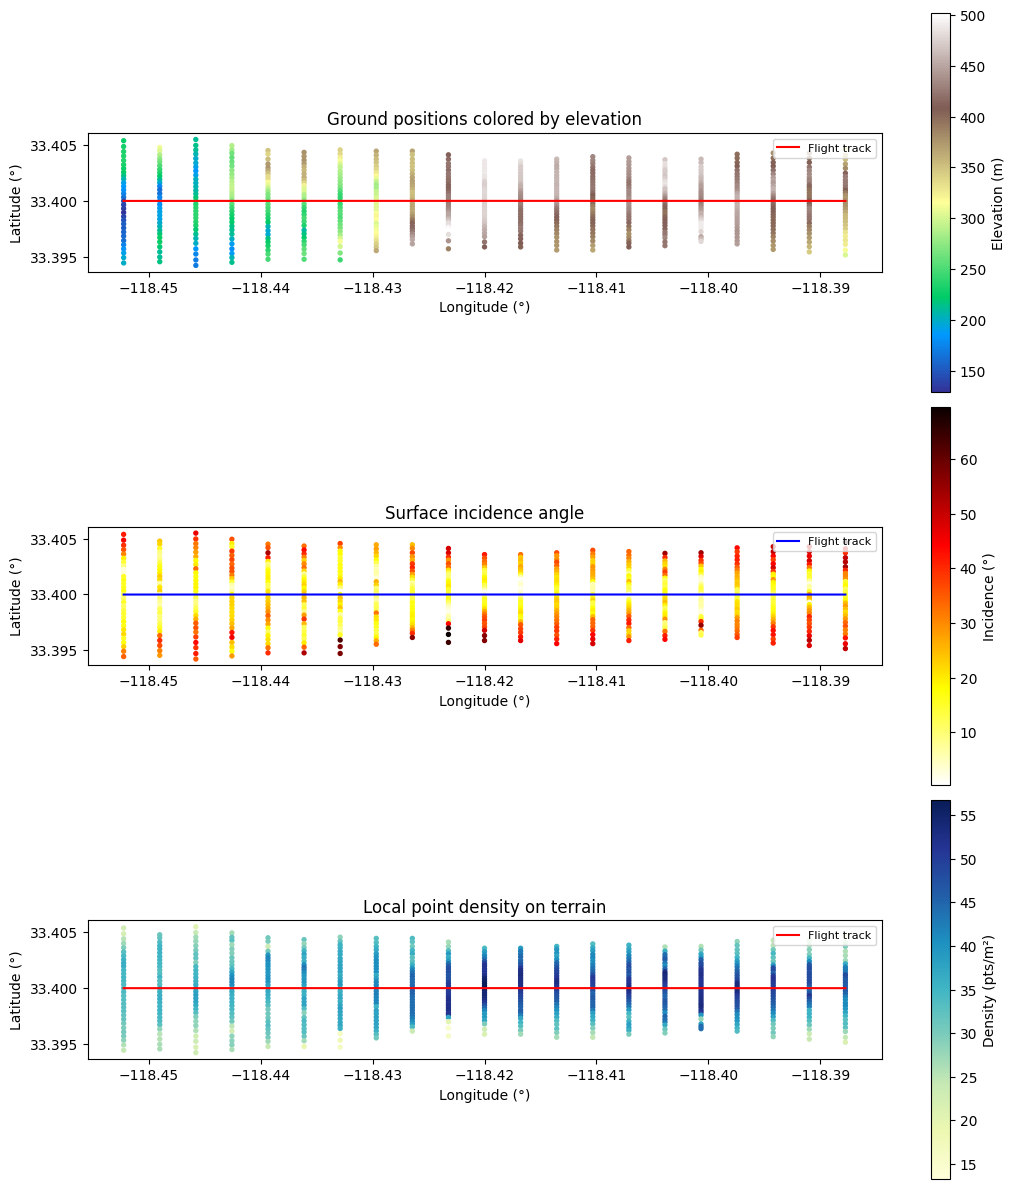

In [15]:
# Geographic maps: where each shot actually landed, colored by metric.
# Stacked vertically to match the elongated east-west flight line.
fig, axes = plt.subplots(3, 1, figsize=(11, 12))

valid = np.isfinite(all_gnd_lats) & np.isfinite(all_gnd_lons)

# (a) Ground elevation
ax = axes[0]
sc = ax.scatter(
    all_gnd_lons[valid], all_gnd_lats[valid],
    c=all_gnd_alts[valid], cmap='terrain', s=8,
)
ax.plot(lons_track, lats_track, 'r-', lw=1.5, label='Flight track')
fig.colorbar(sc, ax=ax, label='Elevation (m)')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Ground positions colored by elevation')
ax.legend(loc='upper right', fontsize=8)
ax.set_aspect('equal')

# (b) Incidence angle
ax = axes[1]
sc = ax.scatter(
    all_gnd_lons[valid], all_gnd_lats[valid],
    c=all_inc[valid], cmap='hot_r', s=8,
)
ax.plot(lons_track, lats_track, 'b-', lw=1.5, label='Flight track')
fig.colorbar(sc, ax=ax, label='Incidence (°)')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Surface incidence angle')
ax.legend(loc='upper right', fontsize=8)
ax.set_aspect('equal')

# (c) Local point density
ax = axes[2]
sc = ax.scatter(
    all_gnd_lons[valid], all_gnd_lats[valid],
    c=all_density[valid], cmap='YlGnBu', s=8,
)
ax.plot(lons_track, lats_track, 'r-', lw=1.5, label='Flight track')
fig.colorbar(sc, ax=ax, label='Density (pts/m²)')
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Local point density on terrain')
ax.legend(loc='upper right', fontsize=8)
ax.set_aspect('equal')

fig.tight_layout()
_show_plot()

**Reading the maps**:

* The terrain profile (panel a) shows the central ridge of Catalina rising above the surrounding sea-level coastline; AGL stays in the 525–856 m band, comfortably within the VQ-480 II envelope.
* The **incidence-angle map** (panel c) is the most informative — on the windward slopes of the ridge, the cross-track scan hits the surface obliquely, sending incidence up to 30–40° on one side of the scan and keeping the other side near nadir.  On flat ground the incidence map would be a clean symmetric chevron with low values everywhere; relief breaks that symmetry.
* The **footprint major axis** (panel d) tracks incidence — it stretches by `1/cos(incidence)` on the high-incidence side.  This is the knob that controls cross-track contiguity on slopes.
* The **local density map** (panel e) shows higher density over high ground (lower AGL, denser pulses per square metre) and lower density over valleys (higher AGL, sparser pulses).  Survey planners care about this directly: a single nominal-AGL density figure can mask a 2× variation across a real survey block.
* The **contiguity mask** (panel f) confirms the survey configuration is contiguous everywhere on this line — relevant to verify before committing flight hours.

The **geographic scatter maps** show the same metrics overlaid on the ground: the actual point cloud delivered to the science team carries this spatial structure, not a uniform set of identical shots.  Terrain-aware analysis is the difference between a survey plan that meets science density requirements *everywhere* and one that only meets them on average.

## 12. Crab-aware swath polygon

When the aircraft flies through a crosswind it crabs into the wind — the aircraft **heading** differs from its **ground track** by the crab angle.  Because the sensor's boresight is fixed to the aircraft body (heading), the swath on the ground is rotated relative to a swath that assumed the boresight followed the track.

`generate_swath_polygon` exposes this via `heading_mode="crabbed"` + either `crab_angle_deg` (added to track) or `heading_deg` (absolute).  Below: same flight line, swath polygon with the boresight aligned to track (default) vs. crabbed 15°.

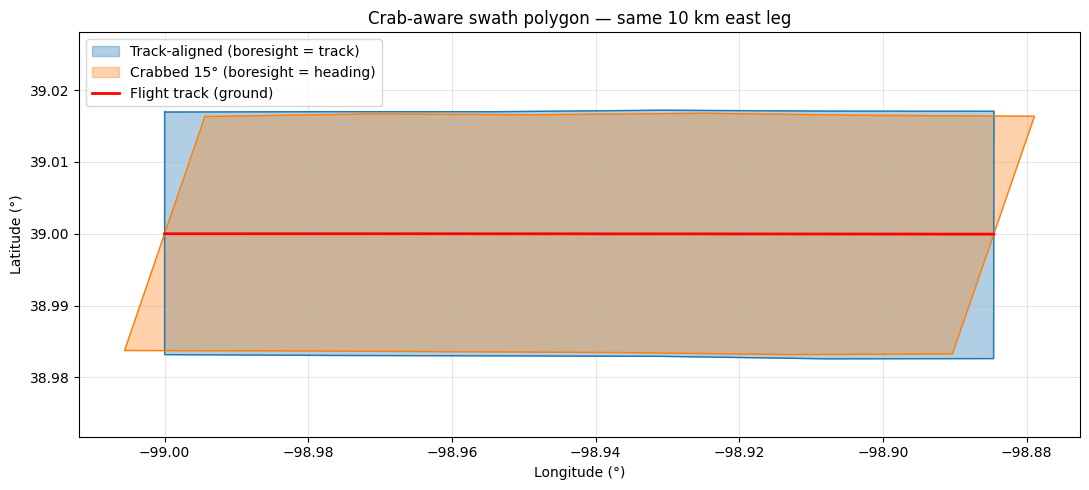

In [16]:
# Same eastbound flight line as section 10.
line = FlightLine.start_length_azimuth(
    lat1=39.0, lon1=-99.0,
    length=10 * ureg.kilometer,
    az=90.0,
    altitude_msl=3000 * ureg.meter,
)

poly_track = generate_swath_polygon(
    line, sensor, along_precision=2000.0,
    heading_mode='track',
)
poly_crabbed = generate_swath_polygon(
    line, sensor, along_precision=2000.0,
    heading_mode='crabbed',
    crab_angle_deg=15.0,
)

fig, ax = plt.subplots(figsize=(11, 5))
for poly, label, color in [(poly_track, 'Track-aligned (boresight = track)', 'C0'),
                            (poly_crabbed, 'Crabbed 15° (boresight = heading)', 'C1')]:
    x, y = poly.exterior.xy
    ax.fill(x, y, alpha=0.35, color=color, label=label)
    ax.plot(x, y, color=color, lw=1)

track = line.track(precision=500.0)
track_lons = [pt[0] for pt in track.coords]
track_lats = [pt[1] for pt in track.coords]
ax.plot(track_lons, track_lats, 'r-', lw=2, label='Flight track (ground)')

ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
ax.set_title('Crab-aware swath polygon — same 10 km east leg')
ax.legend(loc='upper left')
ax.set_aspect('equal', adjustable='datalim')
ax.grid(alpha=0.3)
fig.tight_layout()
_show_plot()

The crabbed swath is rotated about the track — its long axis runs perpendicular to the **aircraft heading**, not the ground track.  When designing a survey block in real wind conditions, pair the planned headings (from `compute_flight_plan(..., wind_field=...)`, which populates `wind_corrected_heading` and `crab_angle_deg` columns) with this option to get the actual ground footprint.

## 13. Multi-lidar rig — the G-LiHT VQ-480i dual configuration

NASA G-LiHT (Goddard's LiDAR, Hyperspectral and Thermal Imager) v.2 (2017+) flies a **dual VQ-480i** scanning lidar configuration.  The user guide (Wirt 2021, LP DAAC §2.8) describes it as *'the Riegl VQ 480i Dual Scanning LiDAR'* but does not publish the tilt angle.  The published combined swath (387 m at 335 m AGL — single-unit ±30° FOV) and combined density (~12 pts/m² — single-unit class) are most consistent with forward/backward pitch tilt of the same cross-track scan, providing multi-angle returns for canopy structure rather than extending swath.

HyPlan exposes the rig via the `MultiALSLidarRig` class (analogous to `MultiCameraRig` for frame cameras) and a `GLIHT_DUAL_VQ_480I` reference instance with units pitch-tilted ±7° (representative; override by constructing the rig directly).

The rig conforms to the `ScanningSensor` protocol and plugs into `generate_swath_polygon` exactly like a single sensor.

In [17]:
from hyplan.instruments import GLIHT_DUAL_VQ_480I, LidarMount, MultiALSLidarRig

rig = GLIHT_DUAL_VQ_480I

print(f'Rig: {rig.name}')
print(f'Units ({len(rig)}):')
for u in rig:
    print(f'  - {u.label!r}: pitch={u.pitch_tilt_deg:+.1f}°  '
          f'roll={u.roll_tilt_deg:+.1f}°  prf={u.lidar.prf:~.0f}')

alt = 335 * ureg.meter      # G-LiHT nominal AGL
gs = 110 * ureg.knot         # G-LiHT nominal groundspeed
print(f'\nAt {alt:~} AGL, {gs:~}:')
print(f'  Combined swath:          {rig.swath_width(alt):~.0f}  '
      f'(user-guide nominal: 387 m)')
print(f'  Combined density:        {rig.combined_point_density(alt, gs):.1f}')
print(f'  Per-unit densities:      '
      f'{ {k: f"{v.magnitude:.1f}" for k, v in rig.unit_point_densities(alt, gs).items()} }')
offsets = rig.along_track_offsets(alt)
print('  Along-track ground offsets:')
for lbl, off in offsets.items():
    print(f'    {lbl!r}: {off:~.1f}')
print()
print('Multi-angle pairs detected:')
for fwd, bwd in rig.multi_angle_pairs():
    print(f'  ({fwd.label!r} {fwd.pitch_tilt_deg:+.1f}°, '
          f'{bwd.label!r} {bwd.pitch_tilt_deg:+.1f}°)')

Rig: G-LiHT Dual VQ-480i (2017+)
Units (2):
  - 'forward': pitch=+7.0°  roll=+0.0°  prf=300000 Hz
  - 'backward': pitch=-7.0°  roll=+0.0°  prf=300000 Hz

At 335 m AGL, 110 kn:
  Combined swath:          387 m  (user-guide nominal: 387 m)
  Combined density:        27.4 / meter ** 2
  Per-unit densities:      {'forward': '13.7', 'backward': '13.7'}
  Along-track ground offsets:
    'forward': 41.1 m
    'backward': -41.1 m

Multi-angle pairs detected:
  ('forward' +7.0°, 'backward' -7.0°)


The forward unit's nadir line projects ~41 m ahead of the aircraft and the backward unit's nadir line projects ~41 m behind — at any given moment they image different ground points, but at a single ground point across the flight pass it's illuminated first by the forward unit, then ~0.75 s later by the backward unit, from two oblique angles.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


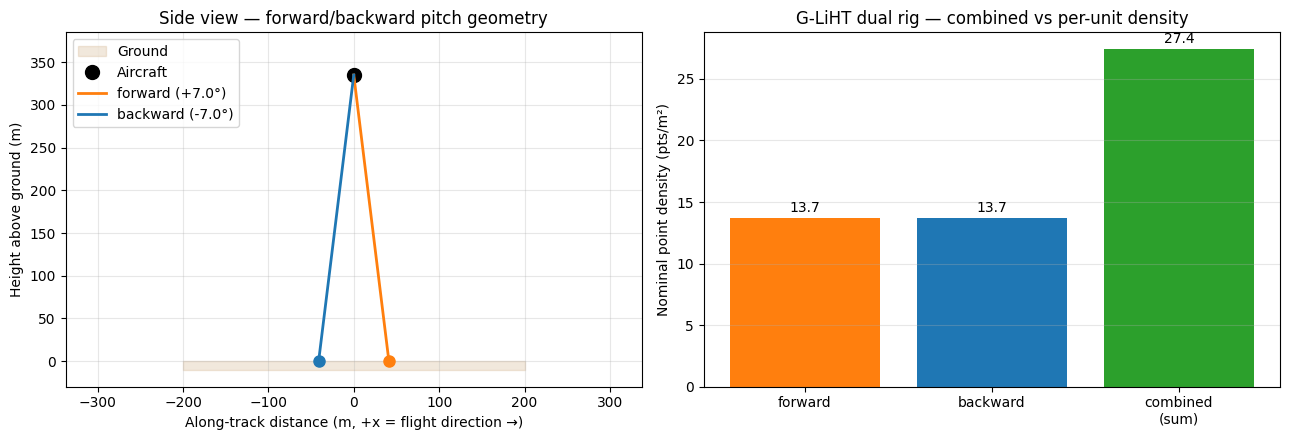

In [18]:
# Side-view sketch of the pitch geometry — same cross-track swath,
# different along-track look angles per unit.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
# Side view: aircraft at (0, AGL), nadir lines projected to ground.
agl = 335.0
ground_x = np.linspace(-200, 200, 100)
ax.fill_between(ground_x, -10, 0, color='tan', alpha=0.3, label='Ground')
ax.plot([0], [agl], 'ko', ms=10, label='Aircraft')
for u in rig:
    tilt = u.pitch_tilt_deg
    # nadir line at this tilt: from aircraft at angle tilt from vertical
    x_ground = agl * np.tan(np.radians(tilt))
    color = 'C1' if tilt > 0 else 'C0'
    ax.plot([0, x_ground], [agl, 0], color=color, lw=2,
            label=f'{u.label} ({tilt:+.1f}°)')
    ax.plot(x_ground, 0, 'o', color=color, ms=8)
ax.set_xlim(-200, 200)
ax.set_ylim(-30, agl + 50)
ax.set_xlabel('Along-track distance (m, +x = flight direction →)')
ax.set_ylabel('Height above ground (m)')
ax.set_title('Side view — forward/backward pitch geometry')
ax.grid(alpha=0.3)
ax.legend(loc='upper left')
ax.set_aspect('equal', adjustable='datalim')

ax = axes[1]
# Density bar: per-unit + combined.
labels = [u.label for u in rig] + ['combined\n(sum)']
unit_d = list(rig.unit_point_densities(alt, gs).values())
combined_d = rig.combined_point_density(alt, gs)
values = [d.m_as(1/ureg.meter**2) for d in unit_d] + [combined_d.m_as(1/ureg.meter**2)]
colors = ['C1', 'C0', 'C2']
bars = ax.bar(labels, values, color=colors)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'{v:.1f}', ha='center', fontsize=10)
ax.set_ylabel('Nominal point density (pts/m²)')
ax.set_title('G-LiHT dual rig — combined vs per-unit density')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
_show_plot()

**Why dual?**  G-LiHT's combined ~27 pts/m² nominal density is higher than the single-unit ~13.7 pts/m², but the bigger win is that every ground point in the swath is sampled from *two* oblique angles.  For canopy lidar this is a substantial advantage — forward-looking and backward-looking shots through a canopy sample different leaf-angle distributions, reduce occlusion shadows behind canopy crowns, and improve 3D structure recovery.  Both units share the same swath polygon, so the rig plugs into `generate_swath_polygon` exactly like a single sensor.

### Roll-tilted alternative — for wider swath

The `MultiALSLidarRig` also supports the orthogonal configuration: two units **roll-tilted** in opposite cross-track directions to extend the combined cross-track swath.  This is a different design choice (wider area, single look angle, single-unit density) and the rig computes it transparently:

In [19]:
from hyplan.instruments import ALSLidar

vq_unit = rig.units[0].lidar
roll_rig = MultiALSLidarRig(
    name='Hypothetical Roll-Tilted Pair (±20°)',
    units=[
        LidarMount(lidar=vq_unit, label='port',      roll_tilt_deg=-20.0),
        LidarMount(lidar=vq_unit, label='starboard', roll_tilt_deg=+20.0),
    ],
)

print('PITCH (G-LiHT)       vs.  ROLL-EXTENDED (hypothetical)')
print('-' * 60)
p_edges = rig.swath_offset_angles()
r_edges = roll_rig.swath_offset_angles()
print(f'Cross-track edges    : {p_edges[0]:+.1f}° to {p_edges[1]:+.1f}°    '
      f'vs  {r_edges[0]:+.1f}° to {r_edges[1]:+.1f}°')
print(f'Combined swath @335m : {rig.swath_width(alt):~.0f}            '
      f'vs  {roll_rig.swath_width(alt):~.0f}')
print(f'Combined density mean: {rig.combined_point_density(alt, gs):.1f}'
      f'  vs  {roll_rig.combined_point_density(alt, gs):.1f}')
print('Multi-angle returns  : YES (2 looks)             '
      'vs  NO (each ground point seen once)')

PITCH (G-LiHT)       vs.  ROLL-EXTENDED (hypothetical)
------------------------------------------------------------
Cross-track edges    : -30.0° to +30.0°    vs  -50.0° to +50.0°
Combined swath @335m : 387 m            vs  798 m
Combined density mean: 27.4 / meter ** 2  vs  13.3 / meter ** 2
Multi-angle returns  : YES (2 looks)             vs  NO (each ground point seen once)


## 14. Adapting the class to other ALS instruments

The class is parameter-driven — adding Leica TerrainMapper or Optech Galaxy is just a datasheet transcription:

```python
MY_SENSOR = ALSLidar(
    name="Vendor Model",
    prf=<PRR> * ureg.kilohertz,
    scan_rate=<scan rate> * ureg.hertz,
    scan_half_angle=<half-FOV> * ureg.degree,
    beam_divergence=<divergence> * ureg.milliradian,
    wavelength=<wavelength> * ureg.nanometer,
    max_range=<range> * ureg.meter,
    mta_zones=<zones>,
    scan_geometry="rotating_polygon_active_arc",  # or rotating_polygon_full_circle
    source="Vendor datasheet, URL, retrieval date",
)
```

Oscillating-mirror scanners (sinusoidal angular velocity) are out of scope in v1 — the constructor raises `ValueError` if you pass `scan_geometry="oscillating_mirror"`.  Those need a different abstraction for per-pulse spacing that's a follow-on contribution.